In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

# Семинар 1 · Ноутбук 1
# Базовые методы прогнозирования

**Что делаем.** Прежде чем брать сложные модели, всегда полезно построить *простые эталонные прогнозы* (baselines). Их роль двойная:

1. они дают точку отсчёта — любую «умную» модель мы будем сравнивать с ними, чтобы убедиться, что она действительно лучше;
2. иногда простой метод оказывается и лучшим из доступных — например, для ряда типа случайного блуждания сложную модель обыграть почти невозможно.

Ноутбук состоит из двух частей:

| Часть | Что делаем |
|---|---|
| **A. «Вручную»** | Реализуем пять базовых методов на чистом `numpy`/`pandas`, чтобы понять их устройство изнутри. |
| **B. «Через фреймворки»** | Повторим ровно то же самое парой строк через `statsforecast`, `sktime` и `etna` — три самых популярных фреймворка для прогнозирования временных рядов на Python. |

**Данные.** Квартальная прибыль на акцию (EPS) компании Johnson & Johnson, 1960–1980.

> **Требуются библиотеки:** `numpy`, `pandas`, `matplotlib`, `statsforecast`, `utilsforecast`, `sktime`, `etna`. Данные — `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/jj.csv`.

---
# 0. Данные и постановка задачи

## 0.1. Загрузка ряда

Столбец `data` — прибыль на акцию (EPS), `date` — дата начала квартала.

In [1]:
# базовые импорты для части A
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/jj.csv"
)
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [2]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


🔍 В сыром CSV даты не идеально регулярны: рядом с `"1980-04-01"` встречается `"1980-07-02"` вместо ожидаемого `"1980-07-01"` — на один день позже. Для человека разница незаметна, но фреймворки в части B строят собственную регулярную сетку дат по параметру `freq` и потом **склеивают** свой прогноз с фактическими значениями по точному совпадению даты. Если дату не поправить, одна из четырёх тестовых точек молча потеряется при склейке, и посчитанная метрика будет отличаться от честной. Поэтому сразу приводим все даты к началу квартала.

In [3]:
# округляем каждую дату до начала её квартала — устраняет расхождение с сеткой фреймворков
df["date"] = pd.to_datetime(df["date"]).dt.to_period("Q").dt.start_time
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-01,16.02
83,1980-10-01,11.61


## 0.2. Train / test split

Оценивать качество прогноза нужно на данных, которые модель «не видела». Отложим последние **4 квартала (1 год)** в тестовую выборку, а всё остальное используем как обучающую. На графике тестовый период выделен серым.

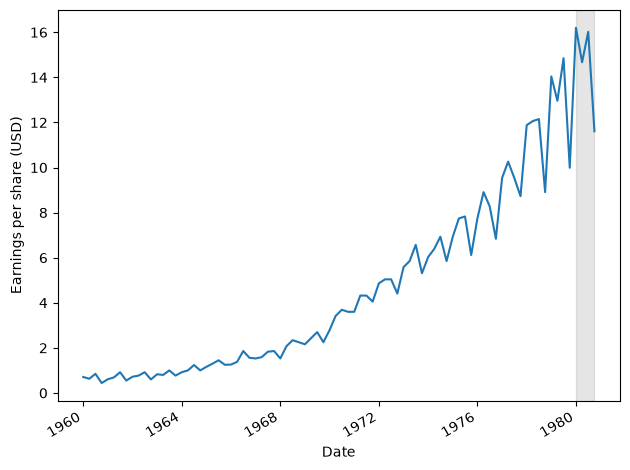

In [4]:
fig, ax = plt.subplots()

ax.plot(df["date"], df["data"])
ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")
ax.axvspan(df["date"].iloc[-4], df["date"].iloc[-1], color="#808080", alpha=0.2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [5]:
# копируем срезы, чтобы дальше свободно добавлять в test колонки с прогнозами
train = df.iloc[:-4].copy()
test = df.iloc[-4:].copy()

print(f"train: {len(train)} наблюдений ({train['date'].min():%Y-%m}…{train['date'].max():%Y-%m})")
print(f"test:  {len(test)} наблюдений ({test['date'].min():%Y-%m}…{test['date'].max():%Y-%m})")

train: 80 наблюдений (1960-01…1979-10)
test:  4 наблюдений (1980-01…1980-10)


## 0.3. Метрика качества: MAPE

Для сравнения методов используем **среднюю абсолютную процентную ошибку**:

$$\mathrm{MAPE} = \frac{100}{h}\sum_{t=n+1}^{n+h}\left|\frac{y_t-\hat y_t}{y_t}\right|.$$

Она безразмерна (в процентах), поэтому её удобно интерпретировать и сравнивать между рядами разного масштаба. Напишем функцию сами — в части B мы возьмём готовые реализации из фреймворков и убедимся, что числа совпадают.

In [6]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## 0.4. Функция для графика прогноза

График «train + test + прогноз» мы будем строить для каждого из пяти методов. Чтобы не копировать один и тот же код пять раз, **вынесем его в отдельную функцию** `plot_forecast`. Меняется только вектор прогноза и заголовок — их и передаём аргументами.

In [7]:
def plot_forecast(train, test, pred, title):
    fig, ax = plt.subplots()

    ax.plot(train["date"], train["data"], "g-.", label="Train")
    ax.plot(test["date"], test["data"], "b-", label="Test")
    ax.plot(test["date"], pred, "r--", label="Predicted")
    ax.set_xlabel("Date")
    ax.set_ylabel("Earnings per share (USD)")
    ax.axvspan(test["date"].iloc[0], test["date"].iloc[-1], color="#808080", alpha=0.2)
    ax.legend(loc=2)
    ax.set_title(title)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

---
# 1. Часть A. Пишем базовые методы руками

Все пять методов ниже — стандартный набор из главы 5.2 книги *Forecasting: Principles and Practice* (Hyndman & Athanasopoulos). Каждый прогноз мы будем складывать в общий словарь `results`, чтобы в конце сравнить их одной диаграммой, не хардкодя числа.

In [8]:
results = {}  # {название метода: MAPE}

## 1.1. Метод 1. Прогноз средним (historical mean)

Все будущие значения полагаем равными среднему по всей истории:

$$\hat y_{n+h|n} = \bar y = \frac1n\sum_{t=1}^{n} y_t.$$

Метод игнорирует и тренд, и сезонность — это самый грубый эталон.

прогноз = 4.31,  MAPE = 70.01%


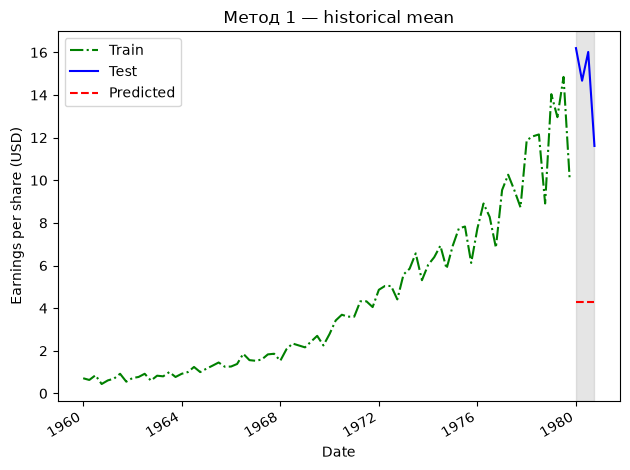

In [9]:
historical_mean = np.mean(train["data"])
pred_mean = np.full(4, historical_mean)

results["mean"] = mape(test["data"], pred_mean)
print(f"прогноз = {historical_mean:.2f},  MAPE = {results['mean']:.2f}%")

plot_forecast(train, test, pred_mean, "Метод 1 — historical mean")

## 1.2. Метод 2. Среднее за последний год (window average)

Тот же прогноз средним, но усредняем только **последние 4 наблюдения**. Так мы частично учитываем текущий уровень ряда и меньше «тянемся» к далёкому прошлому.

прогноз = 12.96,  MAPE = 15.60%


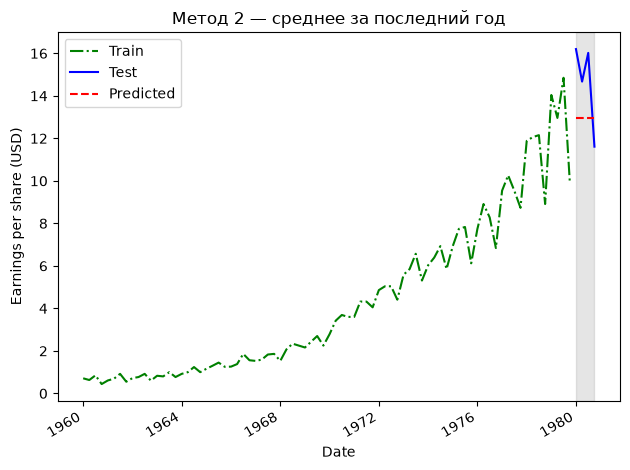

In [10]:
last_year_mean = np.mean(train["data"][-4:])
pred_window = np.full(4, last_year_mean)

results["window4"] = mape(test["data"], pred_window)
print(f"прогноз = {last_year_mean:.2f},  MAPE = {results['window4']:.2f}%")

plot_forecast(train, test, pred_window, "Метод 2 — среднее за последний год")

## 1.3. Метод 3. Наивный прогноз (naive)

Все будущие значения равны **последнему известному** наблюдению:

$$\hat y_{n+h|n} = y_n.$$

Для многих финансовых и экономических рядов это на удивление сильный эталон.

прогноз = 9.99,  MAPE = 30.46%


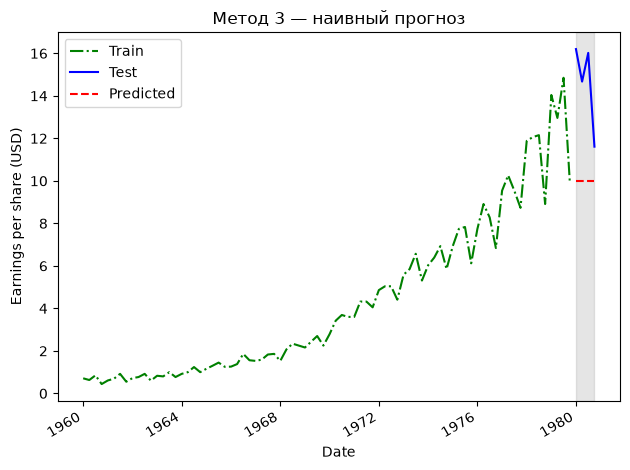

In [11]:
last = train["data"].iloc[-1]
pred_naive = np.full(4, last)

results["naive"] = mape(test["data"], pred_naive)
print(f"прогноз = {last:.2f},  MAPE = {results['naive']:.2f}%")

plot_forecast(train, test, pred_naive, "Метод 3 — наивный прогноз")

## 1.4. Метод 4. Сезонный наивный прогноз (seasonal naive)

Каждый прогноз равен значению из **того же сезона предыдущего цикла**:

$$\hat y_{n+h|n} = y_{n+h-m(k+1)},$$

где $m$ — длина сезона (здесь $m=4$ квартала), а $k$ — целая часть $(h-1)/m$. Для наших 4 кварталов прогноза это просто последние 4 значения обучающей выборки. Такой метод хорошо ловит сезонность.

MAPE = 11.56%


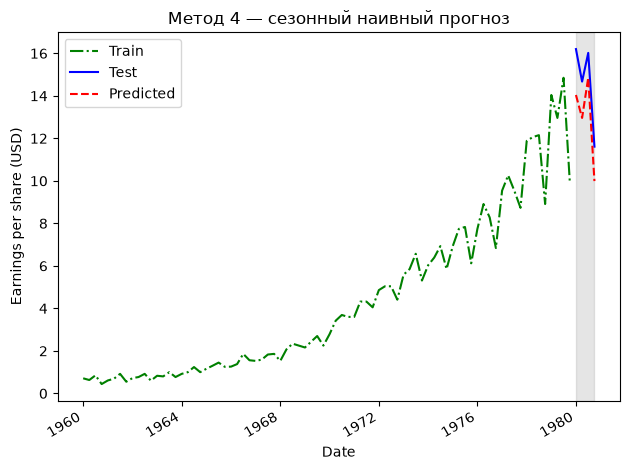

In [12]:
pred_snaive = train["data"][-4:].values

results["snaive"] = mape(test["data"], pred_snaive)
print(f"MAPE = {results['snaive']:.2f}%")

plot_forecast(train, test, pred_snaive, "Метод 4 — сезонный наивный прогноз")

## 1.5. Метод 5. Прогноз со сносом (drift)

Модифицируем наивный прогноз: вместо горизонтальной линии проведём прямую через **первую и последнюю** точки обучающей выборки и экстраполируем её вперёд:

$$\hat y_{n+h|n} = y_{n} + \frac{h}{n-1}\sum_{t=2}^{n}(y_{t}-y_{t-1}) = y_{n} + h\,\frac{y_{n}-y_{1}}{n-1}.$$

Средний прирост ряда за один шаг здесь — это в точности угол наклона прямой, соединяющей первое и последнее наблюдения. В отличие от предыдущих методов, drift умеет учитывать **тренд**.

наклон = 0.117 в квартал,  MAPE = 28.31%


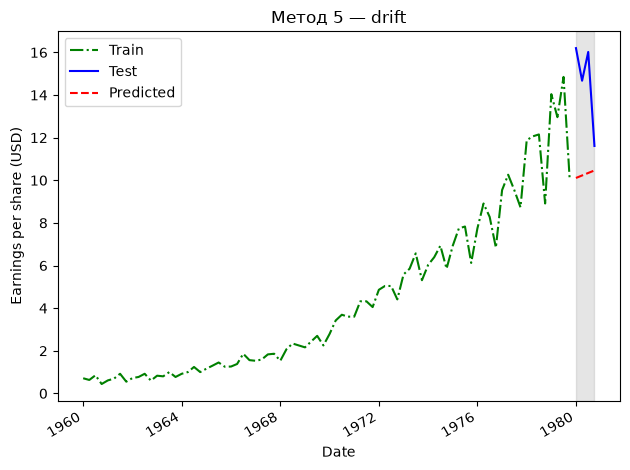

In [13]:
n = len(train)
y_1, y_n = train["data"].iloc[0], train["data"].iloc[-1]
slope = (y_n - y_1) / (n - 1)
pred_drift = y_n + slope * np.arange(1, 5)  # h = 1..4

results["drift"] = mape(test["data"], pred_drift)
print(f"наклон = {slope:.3f} в квартал,  MAPE = {results['drift']:.2f}%")

plot_forecast(train, test, pred_drift, "Метод 5 — drift")

## 1.6. Сравнение методов

Сведём MAPE всех пяти эталонов на одну диаграмму. У ряда J&J есть и восходящий тренд, и годовая сезонность — поэтому ожидаемо, что методы, учитывающие сезонность или тренд (**snaive**, **drift**), точнее, а грубый прогноз средним по всей истории — хуже всех.

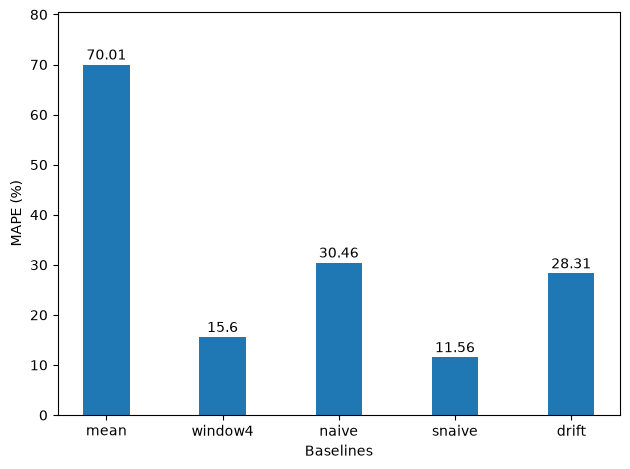

In [14]:
fig, ax = plt.subplots()

names = list(results)
values = [round(v, 2) for v in results.values()]

ax.bar(names, values, width=0.4)
ax.set_xlabel("Baselines")
ax.set_ylabel("MAPE (%)")
ax.set_ylim(0, max(values) * 1.15)

for index, value in enumerate(values):
    ax.text(x=index, y=value + 1, s=str(value), ha="center")

plt.tight_layout()
plt.show()

---
# 2. Часть B. То же самое через фреймворки

Руками писать эти методы на практике не нужно — есть специализированные библиотеки. Зачем вообще фреймворк, если метод умещается в одну строку `numpy`?

- **единый интерфейс** — десятки моделей (от наивных до ARIMA и нейросетей) вызываются одинаково: `fit` / `predict`;
- **масштаб** — одна и та же команда обучает и прогнозирует не один ряд, а тысячи сразу;
- **готовые сплиттеры, метрики, визуализация и доверительные интервалы** — не нужно писать и отлаживать их самому;
- **кросс-валидация «из коробки»** — тема следующего семинара.

Познакомимся с тремя самыми популярными фреймворками и повторим **те же пять методов**, но «из коробки»: **`statsforecast`** (Nixtla), **`sktime`** и **`etna`** (ETNA). Важный принцип: раз уж мы перешли на фреймворки, то и разбиение на train/test, метрики и визуализацию тоже возьмём из самих библиотек, а не будем писать руками.

## 2.0. Общая механика: три шага до прогноза

Как бы по-разному ни выглядел код в трёх библиотеках ниже, внутри происходит одно и то же:

1. **привести ряд к формату библиотеки** — своя структура данных под каждый фреймворк;
2. **обучить модель на train** — `fit`;
3. **запросить прогноз на горизонт `h`**.

Отличаются библиотеки не тем, *что* они делают, а тем, *когда* и *как* сообщается горизонт и где потом лежит обученная модель:

| | контейнер данных | обучение | горизонт задаётся | получение прогноза |
|---|---|---|---|---|
| `statsforecast` | длинный DataFrame `unique_id/ds/y` | `sf.fit(df)` | числом `h` в момент прогноза | `sf.predict(h=4)` или сразу `sf.forecast(df, h=4)` |
| `sktime` | `pd.Series` с временным индексом | `fc.fit(y_train)` | объектом `ForecastingHorizon` | `fc.predict(fh)` |
| `etna` | `TSDataset` | `pipeline.fit(train_ts)` | заранее, в конструкторе `Pipeline(horizon=4)` | `pipeline.forecast()` |

Горизонт — это не свойство модели, а свойство запроса; библиотеки просто по-разному решают, в какой момент его сообщить. Держите эту таблицу в голове — дальше разберём каждую строку подробно.

## 2.1. `statsforecast`

`statsforecast` (экосистема Nixtla) — быстрые статистические модели и эталоны, оптимизированные под работу сразу с большим числом рядов. Данные подаются в «длинном» формате с тремя колонками: `unique_id` (идентификатор ряда), `ds` (дата) и `y` (значение). Класс `StatsForecast` умеет обучать **сразу список моделей** и прогнозировать их одним вызовом `forecast`.

Сопоставление наших пяти методов с моделями библиотеки:

| Метод «вручную» | Модель `statsforecast` |
|---|---|
| прогноз средним | `HistoricAverage()` |
| среднее за последний год | `WindowAverage(window_size=4)` |
| наивный | `Naive()` |
| сезонный наивный | `SeasonalNaive(season_length=4)` |
| drift | `RandomWalkWithDrift()` |

In [15]:
# --- statsforecast: модели и оркестратор ---
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    WindowAverage,
)

# длинный формат: unique_id / ds / y
sf_df = pd.DataFrame(
    {
        "unique_id": "JJ",
        "ds": df["date"],
        "y": df["data"].values,
    }
)
sf_train = sf_df.iloc[:-4]  # тот же train, что и в части A

sf = StatsForecast(
    models=[
        HistoricAverage(),
        WindowAverage(window_size=4),
        Naive(),
        SeasonalNaive(season_length=4),
        RandomWalkWithDrift(),
    ],
    freq="QS",  # квартал (quarter start)
)
fcst = sf.forecast(df=sf_train, h=4)  # прогноз всех пяти моделей сразу
fcst

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


,unique_id,ds,HistoricAverage,WindowAverage,Naive,SeasonalNaive,RWD
0,JJ,1980-01-01,4.3085,12.96,9.99,14.04,10.107468
1,JJ,1980-04-01,4.3085,12.96,9.99,12.96,10.224937
2,JJ,1980-07-01,4.3085,12.96,9.99,14.85,10.342405
3,JJ,1980-10-01,4.3085,12.96,9.99,9.99,10.459873


У `StatsForecast` на самом деле два интерфейса для получения этого же результата:

- `sf.fit(df)` → `sf.predict(h=...)` — привычный по scikit-learn способ: обученные модели остаются внутри объекта (`sf.fitted_`), и `predict` можно вызывать сколько угодно раз с разным горизонтом, не обучая модели заново;
- `sf.forecast(df=..., h=...)`, который мы использовали выше, — «одним движением»: обучает и сразу прогнозирует, **не сохраняя** обученные модели.

Второй путь существует ради масштаба: когда рядов миллионы, хранить обученные объекты для каждого дорого по памяти — поэтому в документации Nixtla именно `forecast` называют production-путём. Проверим, что оба способа дают один и тот же результат.

In [16]:
# тот же результат через классический fit → predict
sf.fit(df=sf_train)
fcst_fp = sf.predict(h=4)

print(
    f"обучено моделей: {sf.fitted_.shape}"
)  # (число рядов, число моделей) — обученные модели лежат внутри объекта
pd.testing.assert_frame_equal(fcst_fp, fcst)  # ошибки нет → оба пути дают одно и то же
fcst_fp

обучено моделей: (1, 5)


,unique_id,ds,HistoricAverage,WindowAverage,Naive,SeasonalNaive,RWD
0,JJ,1980-01-01,4.3085,12.96,9.99,14.04,10.107468
1,JJ,1980-04-01,4.3085,12.96,9.99,12.96,10.224937
2,JJ,1980-07-01,4.3085,12.96,9.99,14.85,10.342405
3,JJ,1980-10-01,4.3085,12.96,9.99,9.99,10.459873


🔍 Раз горизонт передаётся в момент запроса, а не при обучении, ничего не мешает вызвать `sf.predict(h=8)` без повторного `fit` — модели уже обучены. `predict` умеет и `level=[95]`, добавляя доверительные интервалы прямо в таблицу (колонки `Naive-lo-95` / `Naive-hi-95`) — это тема отдельного занятия, но взглянуть стоит уже сейчас. Возьмём для примера только `Naive` — `WindowAverage` из нашего набора интервалы «из коробки» не поддерживает.

In [17]:
sf_naive_only = StatsForecast(models=[Naive()], freq="QS").fit(df=sf_train)
sf_naive_only.predict(h=4, level=[95])

,unique_id,ds,Naive,Naive-lo-95,Naive-hi-95
0,JJ,1980-01-01,9.99,7.723154,12.256846
1,JJ,1980-04-01,9.99,6.784196,13.195804
2,JJ,1980-07-01,9.99,6.063708,13.916292
3,JJ,1980-10-01,9.99,5.456309,14.523691


«Этажом ниже» находится сама модель — она тоже умеет `fit`/`predict`, но работает с голым numpy-массивом, без дат и без имён рядов. `StatsForecast` сверху — это оркестратор: он раскладывает длинный DataFrame по рядам, раздаёт каждому ряду одни и те же модели и собирает результаты обратно в одну таблицу.

In [18]:
# модель без обёртки StatsForecast — минимальный интерфейс, с которым работает оркестратор
m = Naive()
m.fit(y=sf_train["y"].values)
m.predict(h=4)  # словарь {'mean': array([...])} — без дат и unique_id, только числа

{'mean': array([9.99, 9.99, 9.99, 9.99])}

Одна таблица — пять прогнозов. Визуализацию тоже даёт сам фреймворк: у `StatsForecast` есть метод `.plot`, который рисует историю и прогнозы всех моделей.

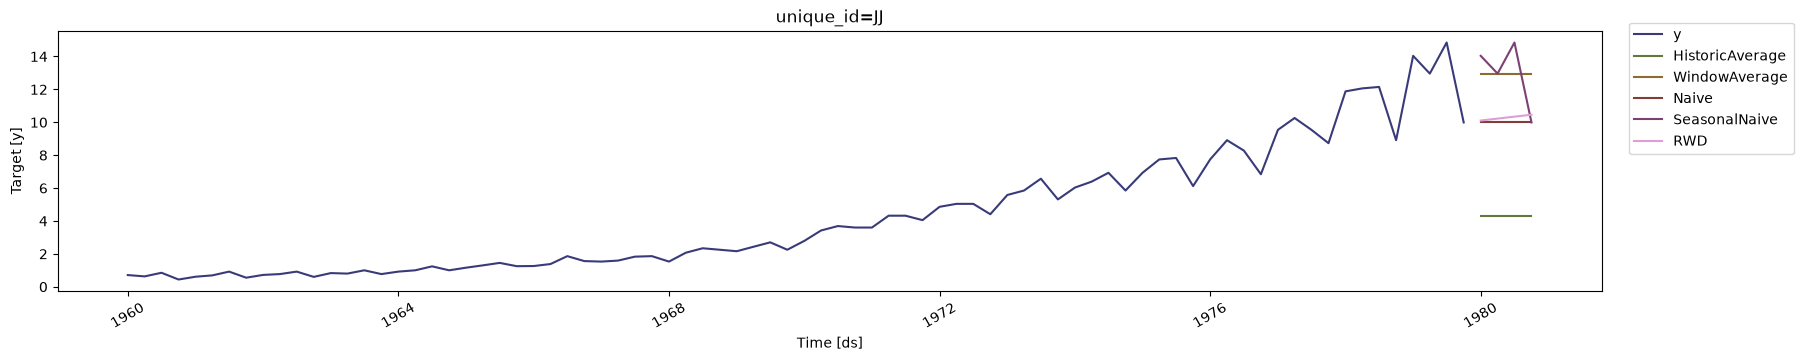

In [19]:
sf.plot(sf_train, fcst)

Метрики — из соседнего пакета экосистемы Nixtla, `utilsforecast`. Функция `evaluate` считает выбранные метрики сразу по всем модельным колонкам; нам нужно лишь подставить фактические значения теста.

🔍 Обратите внимание на `merge` по колонкам `["unique_id", "ds"]` — именно здесь дата, не приведённая к регулярной сетке в разделе 0.1, потеряла бы одну строку теста и незаметно исказила метрику. Проверим явно, что склейка не потеряла ни одной точки.

In [20]:
# добавляем к прогнозам фактические y из теста и оцениваем
eval_df = fcst.merge(sf_df[["unique_id", "ds", "y"]], on=["unique_id", "ds"])
assert len(eval_df) == 4, "после склейки должно остаться 4 тестовые точки — проверьте freq и даты"

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mape as uf_mape

scores_sf = evaluate(eval_df, metrics=[uf_mape])
scores_sf

,unique_id,metric,HistoricAverage,WindowAverage,Naive,SeasonalNaive,RWD
0,JJ,mape,0.700075,0.155964,0.304573,0.115617,0.283139


Значения (в долях, домножьте на 100) совпадают с частью A: `HistoricAverage` ≈ 70.01%, `Naive` ≈ 30.46%, `SeasonalNaive` ≈ 11.56%, `RandomWalkWithDrift` ≈ 28.31% — та же метрика, посчитанная другим кодом, даёт те же числа.

## 2.2. `sktime`

`sktime` устроен как scikit-learn: у каждого прогнозатора есть `.fit()` и `.predict()`, горизонт задаётся объектом `ForecastingHorizon`, а разбиение и визуализация — готовыми функциями библиотеки (`temporal_train_test_split`, `plot_series`).

Все пять методов — это один прогнозатор `NaiveForecaster` с разными параметрами:

| Метод | `NaiveForecaster(...)` |
|---|---|
| прогноз средним | `strategy="mean"` |
| среднее за последний год | `strategy="mean", window_length=4` |
| наивный | `strategy="last"` |
| сезонный наивный | `strategy="last", sp=4` |
| drift | `strategy="drift"` |

In [21]:
# --- sktime: прогнозатор, горизонт, сплиттер, визуализация, метрика ---
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series

# ряд с квартальным периодическим индексом (не датафрейм, а pd.Series — так принято в sktime)
y = pd.Series(df["data"].values, index=pd.PeriodIndex(df["date"], freq="Q"))

# разбиение на train/test — функцией sktime
y_train, y_test = temporal_train_test_split(y, test_size=4)

# горизонт прогноза — на всю тестовую выборку
fh = ForecastingHorizon(y_test.index, is_relative=False)

`.fit(y_train)` запоминает конец обучающей выборки (`cutoff`), а `.predict(fh)` отвечает на вопрос «что будет в этих точках». Горизонт `ForecastingHorizon` бывает двух видов:

- **относительный** — `ForecastingHorizon([1, 2, 3, 4], is_relative=True)`: «на 1–4 шага вперёд от cutoff»;
- **абсолютный** — `ForecastingHorizon(y_test.index, is_relative=False)`: «вот в этих конкретных кварталах» (так мы и делали выше).

Абсолютный вариант удобнее при сверке с тестом: прогноз возвращается с тем же индексом, что и `y_test`, и метрику можно посчитать без ручного выравнивания дат.

In [22]:
# два способа задать один и тот же горизонт
fh_abs = ForecastingHorizon(y_test.index, is_relative=False)  # конкретные кварталы
fh_rel = ForecastingHorizon([1, 2, 3, 4], is_relative=True)  # «на 1..4 шага вперёд»

fc_demo = NaiveForecaster(strategy="last").fit(y_train)
print(f"cutoff обученной модели: {fc_demo.cutoff}")
print(f"оба горизонта дают один прогноз: {fc_demo.predict(fh_rel).equals(fc_demo.predict(fh_abs))}")

cutoff обученной модели: PeriodIndex(['1979Q4'], dtype='period[Q-DEC]', name='date')
оба горизонта дают один прогноз: True


🔍 `fh` можно передать и в `fit`, и в `predict` — тогда во втором вызове его можно не повторять. У прогнозаторов есть и сокращение `fit_predict(y, fh=...)`, а метод `update(y_new)` дообучает модель на новых наблюдениях, не пересобирая её с нуля — ради этого сохраняющий состояние sklearn-подобный интерфейс и нужен.

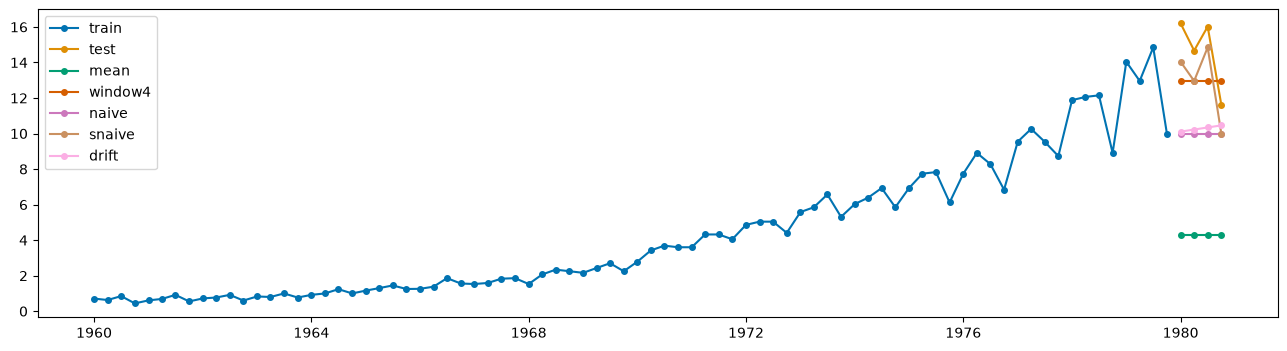

In [23]:
forecasters = {
    "mean": NaiveForecaster(strategy="mean"),
    "window4": NaiveForecaster(strategy="mean", window_length=4),
    "naive": NaiveForecaster(strategy="last"),
    "snaive": NaiveForecaster(strategy="last", sp=4),
    "drift": NaiveForecaster(strategy="drift"),
}

preds = {}
for name, fc in forecasters.items():
    fc.fit(y_train)
    preds[name] = fc.predict(fh)

# визуализация — функцией sktime
plot_series(y_train, y_test, *preds.values(), labels=["train", "test", *preds])
plt.show()

Метрику берём из `sktime.performance_metrics` — объект `MeanAbsolutePercentageError`. Значения совпадают и с частью A, и со `statsforecast`.

In [24]:
mape_metric = MeanAbsolutePercentageError(symmetric=False)  # обычный MAPE (доля)

scores_sktime = pd.DataFrame(
    {
        "метод": list(preds),
        "MAPE, %": [round(mape_metric(y_test, p) * 100, 2) for p in preds.values()],
    }
)
scores_sktime

,метод,"MAPE, %"
0,mean,70.01
1,window4,15.60
2,naive,30.46
3,snaive,11.56
4,drift,28.31


## 2.3. `etna`

`etna` — российский фреймворк для прогнозирования временных рядов, тоже со scikit-learn-подобным API, но с акцентом на готовые пайплайны и бэктестинг «из коробки» (разберём его в следующем семинаре). Здесь формат данных — тема отдельного занятия, поэтому сосредоточимся на **интерфейсе моделей**: `TSDataset` для хранения ряда, `Pipeline` для связки «модель + горизонт», модели из `etna.models`, метрика `MAPE` и функция `plot_forecast`.

| Метод | Модель `etna` |
|---|---|
| прогноз средним | `MovingAverageModel(window=len(train))` |
| среднее за последний год | `MovingAverageModel(window=4)` |
| наивный | `NaiveModel(lag=1)` |
| сезонный наивный | `NaiveModel(lag=4)` |

Готовой модели для drift в `etna` нет — тренд здесь моделируется отдельными трансформами (`LinearTrendTransform`) поверх любой модели, а трансформы — тема отдельного занятия. Поэтому в этом разделе разберём drift оставшиеся четыре метода и сам интерфейс.

In [25]:
# --- etna: контейнер данных, модели, пайплайн, метрика ---
from etna.analysis import plot_forecast as etna_plot_forecast
from etna.datasets import TSDataset
from etna.metrics import MAPE as EtnaMAPE
from etna.models import MovingAverageModel, NaiveModel
from etna.pipeline import Pipeline

# etna ожидает длинный формат с колонками timestamp / segment / target
etna_long = pd.DataFrame(
    {
        "timestamp": df["date"],
        "target": df["data"].values,
        "segment": "JJ",
    }
)
ts = TSDataset(
    TSDataset.to_dataset(etna_long), freq="QS-OCT"
)  # такая метка квартала у pandas не совпадает с "QS", но месяцы те же (янв/апр/июл/окт)
train_ts, test_ts = ts.train_test_split(test_size=4)

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:49: UserWarning: etna[chronos] is not available, to install it, run `pip install etna[chronos]`
  warnings.warn("etna[chronos] is not available, to install it, run `pip install etna[chronos]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:64: UserWarning: etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`
  warnings.warn("etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-pack

`Pipeline` — основной пользовательский интерфейс `etna`: он связывает **трансформы + модель + горизонт** в один объект. Горизонт передаётся в конструктор, а не в момент прогноза, потому что от него зависят сами признаки — например, лаги короче горизонта для прямой стратегии прогнозирования использовать нельзя. То есть в `etna` горизонт это часть конфигурации, а не параметр запроса. Именно поэтому `.forecast()` вызывается без аргументов: пайплайн уже знает и модель, и горизонт, и обучающие данные с `.fit()`.

In [26]:
etna_models = {
    "mean": MovingAverageModel(window=len(train_ts.timestamps)),
    "window4": MovingAverageModel(window=4),
    "naive": NaiveModel(lag=1),
    "snaive": NaiveModel(lag=4),
}

etna_scores = {}
etna_forecasts = {}
for name, model in etna_models.items():
    pipe = Pipeline(model=model, horizon=4)
    pipe.fit(train_ts)
    fc = pipe.forecast()
    etna_forecasts[name] = fc
    etna_scores[name] = EtnaMAPE()(y_true=test_ts, y_pred=fc)["JJ"]

pd.DataFrame({"метод": list(etna_scores), "MAPE, %": [round(v, 2) for v in etna_scores.values()]})

,метод,"MAPE, %"
0,mean,69.50
1,window4,14.66
2,naive,30.46
3,snaive,11.56


🔍 **mean** и **window4** получаются не идентичными части A (≈69.5% вместо 70.01% и ≈14.66% вместо 15.60%), и это не ошибка: `MovingAverageModel` прогнозирует рекурсивно — предсказание на второй, третий и четвёртый квартал строится с учётом уже сделанного прогноза на предыдущий шаг, а не как одно и то же число для всего горизонта. Чем меньше окно усреднения, тем сильнее это накопление сказывается — поэтому у **window4** (окно 4) расхождение заметнее, чем у **mean** (окно на всю обучающую выборку).

Визуализация — функцией `plot_forecast` из `etna.analysis`, она принимает сразу прогноз, train и test:

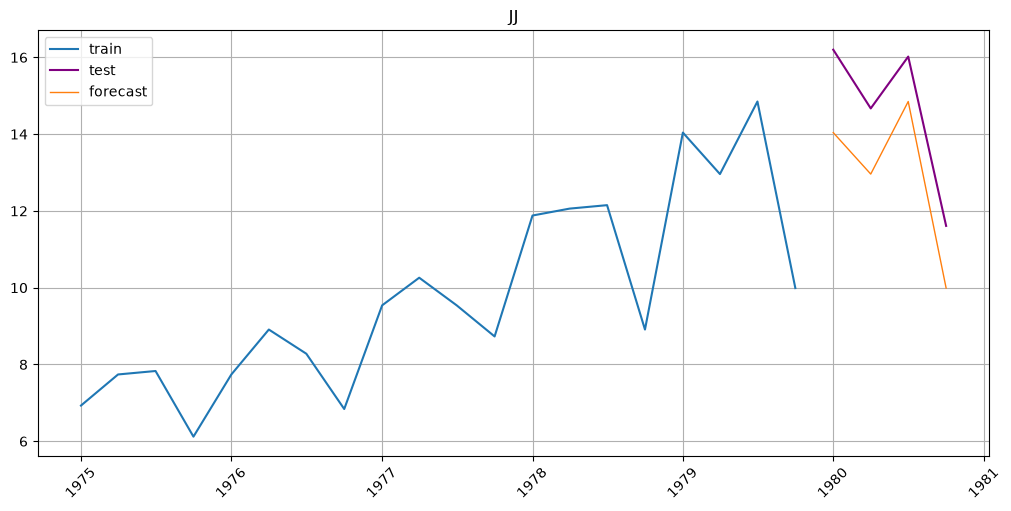

In [27]:
etna_plot_forecast(
    forecast_ts=etna_forecasts["snaive"], test_ts=test_ts, train_ts=train_ts, n_train_samples=20
)

### Что делает `Pipeline` под капотом

Повторим прогноз seasonal naive без `Pipeline`, явно тремя шагами — теми же тремя, что и в общей механике раздела 2.0.

In [28]:
# то же самое вручную, без Pipeline — три явных шага
model = NaiveModel(lag=4)
model.fit(train_ts)  # 1. обучение

future_ts = train_ts.make_future(
    future_steps=4,  # 2. создаём «пустое будущее»
    tail_steps=model.context_size,
)

fc_manual = model.forecast(future_ts, prediction_size=4)  # 3. заполняем его прогнозом
fc_manual[:, "JJ", "target"]

timestamp
1980-01-01    14.04
1980-04-01    12.96
1980-07-01    14.85
1980-10-01     9.99
Freq: QS-OCT, Name: (JJ, target), dtype: float64

🔍 Шаг 2 — то, чего нет в других фреймворках. `etna` требует сначала физически создать будущие строки датасета, потому что по ним считаются признаки (лаги, календарь, результаты трансформов) — модель получает на вход готовую таблицу, а не просто число `h`. `tail_steps=model.context_size` докладывает в будущий кусок хвост истории: сезонному наивному прогнозу с `lag=4` нужно видеть 4 последних квартала обучающей выборки, иначе взять прогноз неоткуда. `Pipeline` делает ровно эти три шага за вас — поэтому на практике пишут именно его, а не работают с моделью напрямую.

In [29]:
# сверка: ручной прогноз и прогноз через Pipeline совпадают
print(f"MAPE вручную:     {EtnaMAPE()(y_true=test_ts, y_pred=fc_manual)['JJ']:.2f}%")
print(f"MAPE через Pipeline: {etna_scores['snaive']:.2f}%")

MAPE вручную:     11.56%
MAPE через Pipeline: 11.56%


---
# 3. Сводная таблица: метод × фреймворк

Соберём MAPE по всем пяти методам из всех четырёх реализаций в одну таблицу.

In [30]:
# приводим имена моделей statsforecast к общим ключам методов
sf_scores = scores_sf.drop(columns=["unique_id", "metric"]).iloc[0] * 100
sf_scores = sf_scores.rename(
    index={
        "HistoricAverage": "mean",
        "WindowAverage": "window4",
        "Naive": "naive",
        "SeasonalNaive": "snaive",
        "RWD": "drift",
    }
)

summary = pd.DataFrame(
    {
        "вручную": pd.Series(results),
        "statsforecast": sf_scores,
        "sktime": scores_sktime.set_index("метод")["MAPE, %"],
        "etna": pd.Series(etna_scores),
    }
)
summary = summary.reindex(["mean", "window4", "naive", "snaive", "drift"]).round(2)
summary.fillna("—")

,вручную,statsforecast,sktime,etna
mean,70.01,70.01,70.01,69.5
window4,15.60,15.60,15.60,14.66
naive,30.46,30.46,30.46,30.46
snaive,11.56,11.56,11.56,11.56
drift,28.31,28.31,28.31,—


Четыре независимые реализации почти во всех клетках дают одно и то же число — разошлись только `mean` и `window4` у `etna`, и мы уже объяснили почему (рекурсивный прогноз `MovingAverageModel`). Прочерк в клетке `etna` × `drift` — не ошибка расчёта, а отсутствие готовой модели drift в библиотеке (раздел 2.3). Это хороший способ проверять себя: если ваш ручной расчёт разошёлся с фреймворком сильнее, чем на пару сотых процента, скорее всего в коде ошибка, а не в округлении.

---
# Итоги

- Простые методы — обязательная точка отсчёта: без них невозможно понять, «хороша» ли сложная модель.
- Выбор эталона зависит от структуры ряда: для данных с сезонностью естественно берётся **сезонный наивный** прогноз, для рядов с трендом — **drift**, для рядов случайного блуждания — обычный **наивный**.
- На практике эти методы не пишут руками: `statsforecast`, `sktime` и `etna` сводят прогноз к паре вызовов `fit`/`predict`, а разбиение, визуализацию и метрики предоставляют «из коробки». Все реализации дают одинаковое ранжирование эталонов и почти идентичные числа.
- `statsforecast` удобен для быстрых статистических моделей и работы сразу с пачкой рядов; `sktime` даёт единый scikit-learn-подобный API; `etna` делает акцент на готовые пайплайны и бэктестинг. Дальше в курсе мы будем использовать все три.
- Механика получения прогноза везде одна и та же: формат данных → `fit` на train → запрос горизонта. Различаются библиотеки только тем, **когда** сообщается горизонт: `statsforecast` — числом `h` в момент запроса (`predict`/`forecast`), `sktime` — объектом `ForecastingHorizon` (относительным или абсолютным), `etna` — заранее, в конструкторе `Pipeline`.
- Приведение дат к регулярной сетке (раздел 0.1) — не формальность: без него метрики, посчитанные фреймворками, различались бы с ручным расчётом, хотя код был бы формально правильным.